In [1]:
%matplotlib widget

from pathlib import Path
import json

import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

DPI = plt.rcParams['figure.dpi']

In [2]:
class EventsAnnotator:
    def __init__(self, emg_events, glove_events):
        if len(emg_events) != len(glove_events):
            raise ValueError(
                'Arrays have different numbers of events'
            )
            
        self.emg_events = emg_events
        self.glove_events = glove_events

        self.points = []

        self.fig = None
        self.ax = None

        self._key_press_cid = None

        self._markers = []
        self._bars_centers = []

        self._active = False


    def show_plots(self, figsize=(10, 10)):
        if self.fig is not None and plt.fignum_exists(self.fig.number):
            return

        self.fig, self.ax = plt.subplots(
            1,
            1,
            figsize=figsize,
            sharex=False,
            constrained_layout=True,
        )

        sns.barplot(
            x=self.emg_events,
            y=self.glove_events - self.emg_events,
            ax=self.ax
        )

        self._redraw_existing_markers()

        self._active = True

        self._key_press_cid = self.fig.canvas.mpl_connect(
            "key_press_event",
            self._on_key_press,
        )

        plt.show()

    def _on_key_press(self, event):
        if not self._active:
            return
    
        if event.inaxes is None:
            return
    
        if event.key == "a":
            if event.xdata is None:
                return
    
            x = round(float(event.xdata))
            self._add_point(x)
    
        elif event.key == "u":
            self._remove_last_point()
    
        else:
            return
    
        self.fig.canvas.draw_idle()

    
    def _add_point(self, x):
        self.points.append(x)

        marker = self.ax.axvline(
            x,
            linestyle="--",
            linewidth=1.2,
        )

        self._markers.append(marker)

    
    def _remove_last_point(self):
        if not self.points:
            return
    
        x = self.points.pop()
    
        marker = self._markers.pop()
        marker.remove()

    
    def _redraw_existing_markers(self):
        """
        Нарисовать ранее созданные метки после повторного открытия фигуры.
        """

        self._markers = []

        for x in self.points:
            marker = self.ax.axvline(
                x,
                linestyle="--",
                linewidth=1.2,
            )
            self._markers.append(marker)
    
    def finish(self):
        """
        Завершить разметку и закрыть фигуру.
        """

        self._active = False

        if self.fig is None:
            return

        # Отключаем event handler
        if self._key_press_cid is not None:
            self.fig.canvas.mpl_disconnect(self._key_press_cid)
            self._key_press_cid = None

        plt.close(self.fig)

        self.fig = None
        self.ax = None

        self._markers = []

---

### TO DO:
1. Load data (emg, markup, quaternions, accelerometers)
2. Load events timestamps
3. Visualise dependencies between emg and glove events
4. Train regression model
5. Extract the weight and the bias
6. Transform glove timestamps
7. Visualise the result

---

In [3]:
tmp_folder = Path('./tmp/data/')

In [4]:
participant_id = 23
participant_folder_dir = tmp_folder / str(participant_id)

with h5py.File(participant_folder_dir / f'{participant_id}.hdf5', mode='r') as hdf_file:
    emg_data = hdf_file.get('emg')[:]
    lia_norm_data = hdf_file.get('lia_norm')[:]

with open(participant_folder_dir / 'emg_events.json') as json_file:
    events = json.load(json_file)
    emg_events = np.array(events['points']).reshape(-1, 2)
    emg_anomaly_events = np.array(events['anomaly_points']).reshape(-1, 2)

with open(participant_folder_dir / 'glove_events.json') as json_file:
    events = json.load(json_file)
    glove_events = np.array(events['points']).reshape(-1, 1)
    glove_anomaly_events = np.array(events['anomaly_points']).reshape(-1, 1)

more_events = None
if emg_events.shape[0] != glove_events.shape[0]:
    print(f'EMG ({emg_events.shape[0]}) and glove ({glove_events.shape[0]}) have different number of events\n')

    more_events = 'glove' if emg_events.shape[0] < glove_events.shape[0] else 'emg'

    for idx, (g, e) in enumerate(
        zip(
            np.diff(np.squeeze(glove_events)),
            np.diff(np.squeeze(emg_events[:, 0]))
        ),
        start=1
    ):
        print(f'{idx:3}: {g:6.3f}; {e:6.3f}')

EMG (106) and glove (105) have different number of events

  1: 15.966; 12.723
  2: 13.839; 14.938
  3: 16.184; 13.879
  4: 13.687; 16.050
  5: 15.598; 14.068
  6: 15.011; 15.112
  7: 16.184; 15.186
  8: 14.255; 16.572
  9: 15.196; 13.580
 10: 14.629; 15.259
 11: 15.865; 14.479
 12: 16.407; 15.843
 13: 15.561; 16.329
 14: 13.453; 15.600
 15: 15.045; 13.312
 16: 15.440; 15.988
 17: 15.188; 14.407
 18: 15.480; 15.210
 19: 15.748; 15.355
 20: 13.620; 15.696
 21: 16.050; 13.677
 22: 15.865; 16.110
 23: 13.721; 15.673
 24: 15.430; 13.701
 25: 16.720; 15.478
 26: 15.267; 15.817
 27: 12.920; 15.989
 28: 15.965; 12.825
 29: 15.355; 15.964
 30: 14.968; 15.308
 31: 15.799; 14.990
 32: 14.739; 15.673
 33: 13.785; 14.771
 34: 16.334; 13.701
 35: 14.190; 16.378
 36: 16.585; 14.115
 37: 12.869; 16.791
 38: 16.465; 13.093
 39: 14.190; 15.916
 40: 17.306; 14.188
 41: 14.746; 17.473
 42: 16.251; 14.797
 43: 13.520; 15.818
 44: 17.021; 14.238
 45: 13.087; 16.199
 46: 17.141; 13.117
 47: 12.866; 17.060
 

In [5]:
if more_events:
    idx_to_remove = 0
    if more_events == 'glove':
        glove_events = np.delete(glove_events, idx_to_remove)
    else:
        emg_events = np.delete(emg_events, idx_to_remove, axis=0)

    for idx, (g, e) in enumerate(
        zip(
            np.diff(np.squeeze(glove_events)),
            np.diff(np.squeeze(emg_events[:, 0]))
        ),
        start=1
    ):
        print(f'{idx:3}: {g:6.3f}; {e:6.3f}')

    with open(participant_folder_dir / 'remove_index.txt', mode='w') as txt_file:
        txt_file.write(str(idx_to_remove))

  1: 15.966; 14.938
  2: 13.839; 13.879
  3: 16.184; 16.050
  4: 13.687; 14.068
  5: 15.598; 15.112
  6: 15.011; 15.186
  7: 16.184; 16.572
  8: 14.255; 13.580
  9: 15.196; 15.259
 10: 14.629; 14.479
 11: 15.865; 15.843
 12: 16.407; 16.329
 13: 15.561; 15.600
 14: 13.453; 13.312
 15: 15.045; 15.988
 16: 15.440; 14.407
 17: 15.188; 15.210
 18: 15.480; 15.355
 19: 15.748; 15.696
 20: 13.620; 13.677
 21: 16.050; 16.110
 22: 15.865; 15.673
 23: 13.721; 13.701
 24: 15.430; 15.478
 25: 16.720; 15.817
 26: 15.267; 15.989
 27: 12.920; 12.825
 28: 15.965; 15.964
 29: 15.355; 15.308
 30: 14.968; 14.990
 31: 15.799; 15.673
 32: 14.739; 14.771
 33: 13.785; 13.701
 34: 16.334; 16.378
 35: 14.190; 14.115
 36: 16.585; 16.791
 37: 12.869; 13.093
 38: 16.465; 15.916
 39: 14.190; 14.188
 40: 17.306; 17.473
 41: 14.746; 14.797
 42: 16.251; 15.818
 43: 13.520; 14.238
 44: 17.021; 16.199
 45: 13.087; 13.117
 46: 17.141; 17.060
 47: 12.866; 12.897
 48: 15.446; 15.381
 49: 16.586; 16.572
 50: 13.622; 13.750


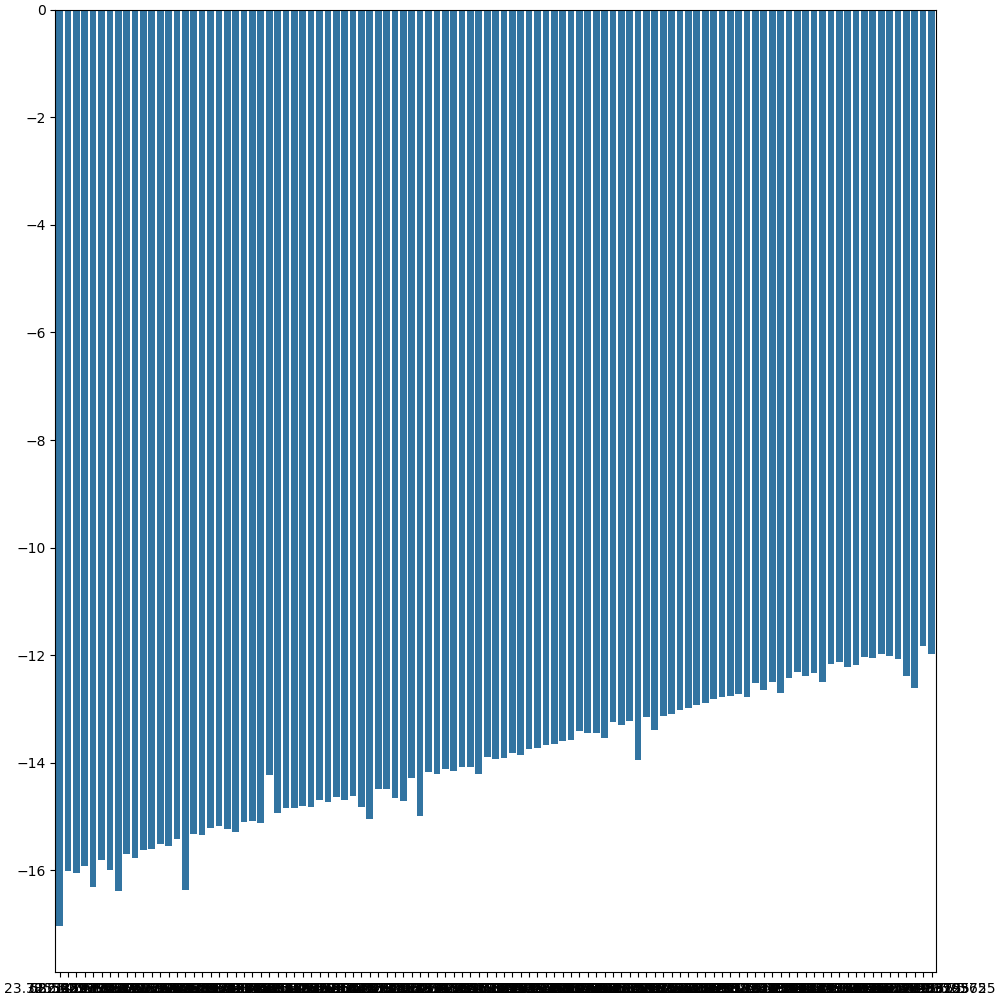

In [6]:
annotator = EventsAnnotator(emg_events[:, 0], np.squeeze(glove_events))

annotator.show_plots()

In [7]:
annotator.finish()

In [8]:
events_indeces_with_big_difference = annotator.points[:]

with open(participant_folder_dir / 'events_indeces_with_big_difference.json', mode='w') as json_file:
    json.dump(events_indeces_with_big_difference, json_file)

glove_events = np.delete(np.squeeze(glove_events), events_indeces_with_big_difference)
emg_events = np.delete(np.squeeze(emg_events[:, 0]), events_indeces_with_big_difference)

In [9]:
model = LinearRegression()
model.fit(glove_events.reshape(-1, 1), emg_events.reshape(-1, 1))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


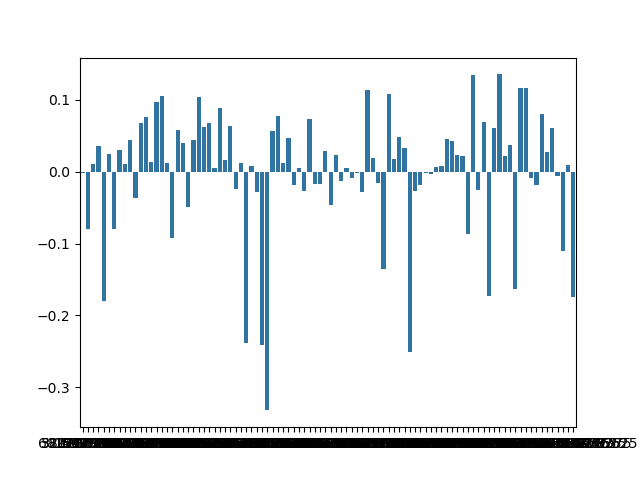

In [10]:
plt.close()
new_glove_events = glove_events * model.coef_[0, 0] + model.intercept_

sns.barplot(
        x=emg_events,
        y=new_glove_events - emg_events,
    )

plt.show()

In [11]:
with open(participant_folder_dir / 'glove_to_emg_coefs.json', mode='w') as json_file:
    json.dump(
        {
            'intercept': model.intercept_[0],
            'coef': model.coef_[0, 0]
        },
        json_file)